# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [46]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') 
usage = pd.read_csv('/datasets/usage.csv')     

In [5]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:

# cantidad de nulos para users
users.isna().sum()
users.isna().mean()
print("Cantidad de valores nulos:", users.isna().sum())
print ("=============================")  #saldo de linea
print("Proporción de valores nulos:", users.isna().mean())



Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos: user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:

# cantidad de nulos para usage
usage.isna().sum()
usage.isna().mean()
print("Cantidad de valores nulos:", usage.isna().sum())
print ("=============================")  #saldo de linea
print("Proporción de valores nulos:", usage.isna().mean())



Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
- 
*Dataset: users*
**churn_date** (88.35% de nulos):

Qué se observa: Falta la gran mayoría de los datos, pero esto indica que el 88.35% de los usuarios siguen activos.

Acción recomendada: Ignorar / Mantener, ya que considerar Eliminarla destruiría información clave de negocio, y no se debe imputar porque el nulo tiene un significado real (usuario activo).

**city** (11.73% de nulos):

Qué se observa: Falta poco más del 11% de las ciudades, una proporción moderada que afecta la segmentación geográfica.

Acción recomendada: Imputar con una categoría fija (ej. "Unknown"). Esto evita perder el 11% de los perfiles de usuario al hacer análisis o agrupaciones por ciudad.

*Dataset: usage*
**date** (0.125% de nulos):

Qué se observa: La cantidad de registros sin fecha es insignificante (solo 50 filas de 40,000).

Acción recomendada: Eliminar estas 50 filas. Al ser menos del 1%, borrarlas no sesga el dataset y limpia los registros que no se pueden mapear en el tiempo.

**duration** (55.19% de nulos) y **length** (44.74% de nulos):

Qué se observa: Proporciones muy altas de nulos que dependen del tipo servicio de la columna (type), donde las llamadas no tienen longitud y el Texto no tiene duracion.

Acción recomendada: Imputar con 0. No se deben eliminar porque son nulos estructurales; rellenar con cero permite sumar minutos o megabytes correctamente sin perder registros.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
print("Resumen Estadístico del dataset USERS:")
print("-"*40 )
print(users.describe())
print("-"*40 )

Resumen Estadístico del dataset USERS:
----------------------------------------
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
----------------------------------------


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
-Tiene un conteo de 4000 registros, con valores que van consecutivamente desde el 10000 hasta el 13999.
-Es una columna de identificación (ID) completamente limpia, sin valores nulos y con una distribución uniforme esperada para un índice de usuarios.
  
- La columna `age`
- El valor mínimo es -999, lo cual es un error evidente, y la desviación estándar (std) es extremadamente alta (123.23), inflada por ese número. Además, la mediana (50%) es 47, pero la media (mean) baja a 33.73 debido al peso de esos valores negativos tan grandes.
- El valor -999 es un "outlier" (valor atípico) que se introdujo probablemente como un código de error de captura o para representar datos faltantes ocultos. Es necesario filtrar y limpiar estos valores negativos antes de hacer cualquier análisis de edad, ya que están sesgando por completo el promedio real del dataset.

In [32]:
# explorar columnas numéricas de usage
print("Resumen Estadístico del dataset USAGE:")
print("-"*60 )
print(usage.describe())
print("-"*60 )


Resumen Estadístico del dataset USAGE:
------------------------------------------------------------
                id       user_id      duration        length       is_text  \
count  40000.00000  40000.000000  17924.000000  22104.000000  40000.000000   
mean   20000.50000  12002.405975      5.202237     52.127398      0.552300   
std    11547.14972   1157.279564      6.842701     56.611183      0.497263   
min        1.00000  10000.000000      0.000000      0.000000      0.000000   
25%    10000.75000  10996.000000      1.437500     37.000000      0.000000   
50%    20000.50000  12013.000000      3.500000     50.000000      1.000000   
75%    30000.25000  13005.000000      6.990000     64.000000      1.000000   
max    40000.00000  13999.000000    120.000000   1490.000000      1.000000   

            is_call  
count  40000.000000  
mean       0.447700  
std        0.497263  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        1.000000  
max        1.000000  

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.


-Ambas tienen el conteo completo de 40,000 registros (sin nulos en su estructura numérica). la columna (id) va del 1 al 40,000 en orden consecutivo, y (user_id) se mantiene estrictamente en el rango de los usuarios que describimos antes (10,000 a 13,999).Son llaves e identificadores correctos y consistentes. No presentan anomalías y sirven perfectamente para unir (merge) esta tabla con la de usuarios.

-Las columnas duration y length: Sus conteos (count) suman exactamente 40,028 filas (17,924 + 22,104), lo que confirma la teoria de que no se solapan (cuando hay duración no hay longitud, y viceversa). El valor mínimo en ambas es 0.0, lo cual es normal para intentos de conexión o llamadas perdidas.
-Los promedios son bajos (5.2 minutos y 52 MB), pero los valores máximos (max) son extremadamente altos: una llamada de 120 minutos (2 horas) y una sesión de datos de 1,490 MB (1.5 GB). Estos valores máximos actúan como "outliers" (valores atípicos) que inflan la desviación estándar (std), por lo que vale la pena revisarlos para ver si son consumos reales de usuarios intensivos o anomalías del sistema.

In [33]:
# Explorar columnas categóricas de users
print("Valores únicos en las columnas categoricas de Users (City y Plan):")
print()
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].unique())
    print("-"*50 )     

Valores únicos en las columnas categoricas de Users (City y Plan):

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
--------------------------------------------------
['Basico' 'Premium']
--------------------------------------------------


In [34]:
# Conteo de registros únicos en las columnas categoricas de Users
print("Conteo de registros unicos en la columna (City):")
print(users['city'].value_counts())
print("-"*50 + "\n")

print("Conteo de registros unicos en la columna (Plan):")
print(users['plan'].value_counts())
print("-"*50)

Conteo de registros unicos en la columna (City):
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64
--------------------------------------------------

Conteo de registros unicos en la columna (Plan):
Basico     2595
Premium    1405
Name: plan, dtype: int64
--------------------------------------------------


- La columna `city` ...Aparecen los nombres de varias ciudades de México y Colombia, el valor nan (los nulos que se habian detectado) y, lo más importante, un signo de interrogación '?'.

El caracter '?' funciona exactamente como un valor nulo oculto (una falta de datos que el sistema registró con ese símbolo en lugar de dejarlo vacío). Se debe reemplazar ese '?' por nan para que se sume al conteo real de datos faltantes y se pueda tratar correctamente.

- La columna `plan` ... Muestra únicamente dos valores posibles: 'Basico' y 'Premium', sin caracteres extraños ni valores nulos visibles.
- Es una variable categórica limpia y perfectamente estructurada, Lista para ser utilizada como grupo de control para comparar los consumos o el abandono (churn_date) entre ambos tipos de clientes.

In [35]:
# Explorar columna categórica de usage
print("Valores únicos en la columna 'type':")
print(usage['type'].unique())
print("-"*40 + "\n")

# Conteo de registros por cada tipo de servicio
print("Conteo de registros por categoría:")
print(usage['type'].value_counts())
print("-"*40)

Valores únicos en la columna 'type':
['call' 'text']
----------------------------------------

Conteo de registros por categoría:
text    22092
call    17908
Name: type, dtype: int64
----------------------------------------


- La columna `type` ...


Contiene exactamente dos categorías únicas: 'text' (mensajes de texto) y 'call' (llamadas), con un conteo de 22,092 registros para texto y 17,908 para llamadas.
Es una columna limpia, sin valores nulos ni caracteres extraños. Además, el conteo confirma nuestra hipótesis anterior: los 22,092 registros de 'text' equivalen casi exactamente a los nulos en duration (minutos), y los 17,908 registros de 'call' coinciden con los nulos de length (datos/mensajes), demostrando que el dataset está bien estructurado según el tipo de servicio.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías? 
-**age** (Valor centinela: -999), La columna presenta un valor mínimo de -999, lo cual es un error evidente utilizado como código para representar datos faltantes u ocultos.
-Acción: Reemplazar por NaN e imputar. Se deben transformar estos valores a nulos reales para luego imputarlos con la mediana de la edad (que es 47 años), evitando así que el promedio se altere.
-**city** (Valor inválido: '?'):Aparece el carácter (?) dentro de la lista de ciudades únicas, actuando como un registro inválido o nulo.
-Acción: Reemplazar por NaN y agrupar. Se debe convertir el signo de interrogación en un nulo estándar para procesarlo junto con el 11.73% de nulos ya existentes bajo la etiqueta "Unknown".

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [36]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")
print(users['reg_date'].head())             # completa el código

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [37]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")
print(usage['date'].head())                     # completa el código

0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


In [21]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()
print(users['reg_date'].dt.year.unique())
print(users['reg_date'].min())
print(users['reg_date'].max())
print(users['reg_date'].dt.year.value_counts())


[2022 2026 2023 2024]
2022-01-01 00:00:00
2026-05-10 00:00:00
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
-Al analizar la columna reg_date, que almacena la fecha de alta de los usuarios en la plataforma, se observa el siguiente comportamiento:
Los registros de los usuarios están distribuidos entre los años [2022] y [2026].
El año con mayor número de registros de nuevos usuarios es [2024], acumulando un total de [1330] usuarios.
No se detectaron valores nulos (NaT) ni inconsistencias cronológicas; todas las fechas guardan una coherencia lógica con el histórico del sistema.

In [38]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()
print(usage['date'].dt.year.unique())
print(usage['date'].min())
print(usage['date'].max())


[2024.   nan]
2024-01-01 00:00:00
2024-06-30 00:00:00


En `date`, ... haz doble clic en este bloque y escribe qué ves.

-Al revisar los datos de la columna date en la tabla usage, se observa lo siguiente:
-Rango de tiempo: Los datos válidos abarcan exactamente el primer semestre del año 2024, iniciando el 2024-01-01 y terminando el 2024-06-30.
-Años presentes: El único año registrado con datos válidos es 2024.

-Calidad de datos: Se detectó la presencia de valores nulos (nan). Esto significa que la conversión forzó a tipo fecha algunos registros vacíos o con errores de formato.

-Basaremos el análisis en este periodo del primer semestre de 2024.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos).
  -No aparecen años imposibles en los registros válidos. El único año presente es 2024, y las fechas están lógicamente acotadas en el primer semestre (del 1 de enero al 30 de junio de 2024). No hay registros de años muy antiguos ni futuros. El único problema detectado es la presencia de valores nulos (nan).

- ¿Qué harías con ellas?
- Para los valores nulos (nan): Como se trata de un análisis de uso en el tiempo, un registro sin fecha carece de utilidad. Recomiendo eliminar estas filas del análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [39]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [40]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [41]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [42]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`
-Al agrupar los datos faltantes por la variable type, se confirma un patrón claro de datos faltantes de tipo MAR (Missing At Random) debido a la naturaleza de los servicios:

-Para duration (Duración): Solo presenta valores nulos (22,076 registros) cuando el tipo es text. Esto es completamente lógico, ya que los mensajes de texto no tienen una duración en tiempo, mientras que las llamadas (call) registran 0 nulos.

-Para length (Longitud): Solo presenta valores nulos (17,896 registros) cuando el tipo es call. Esto se debe a que las llamadas telefónicas no tienen una longitud de caracteres, propiedad que sí es exclusiva de los mensajes de texto (text), los cuales registran 0 nulos.

-Conclusión: La falta de datos no es accidental ni aleatoria sino que depende directamente del tipo de servicio registrado en la columna type.




---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [54]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

#converiosion de dato de decimal a minutos y segundos reales de la columna "duration"

usage["duration"] = pd.to_numeric(usage["duration"], errors='coerce').fillna(0)
minutos_enteros = usage["duration"].astype(int)
segundos_decimales = np.round((usage["duration"] % 1) * 100) / 60
usage["duration_minutes_tot"] = minutos_enteros + segundos_decimales

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration_minutes_tot": "sum" 
}).reset_index()

# observar resultado
usage_agg.head(5)

,user_id,is_text,is_call,duration_minutes_tot
0,10000,7,3,24.833333
1,10001,5,10,36.633333
2,10002,5,2,11.233333
3,10003,11,3,10.316667
4,10004,4,3,9.350000


In [55]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration_minutes_tot": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,24.833333
1,10001,5,10,36.633333
2,10002,5,2,11.233333
3,10003,11,3,10.316667
4,10004,4,3,9.350000


In [74]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on='user_id')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,24.833333,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,36.633333,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,11.233333,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,10.316667,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,9.350000,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [78]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ["cant_mensajes","cant_llamadas","cant_minutos_llamada", "age"]
print ("Resumen Estadístico de las columnas numéricas")
print("_"*70)
print(user_profile[columnas_numericas].describe())


Resumen Estadístico de las columnas numéricas
______________________________________________________________________
       cant_mensajes  cant_llamadas  cant_minutos_llamada          age
count    3999.000000    3999.000000           3999.000000  3999.000000
mean        5.524381       4.478120             24.751063    48.124531
std         2.358416       2.144238             18.605725    17.692032
min         0.000000       0.000000              0.000000    18.000000
25%         4.000000       3.000000             12.150000    33.000000
50%         5.000000       4.000000             21.133333    47.000000
75%         7.000000       6.000000             33.141667    63.000000
max        17.000000      15.000000            158.150000    79.000000


In [86]:
# Distribución porcentual del tipo de plan
print ("Distribución porcentual del tipo de plan")
print("_"*40)
print(user_profile["plan"].value_counts(normalize=True) * 100)


Distribución porcentual del tipo de plan
________________________________________
Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

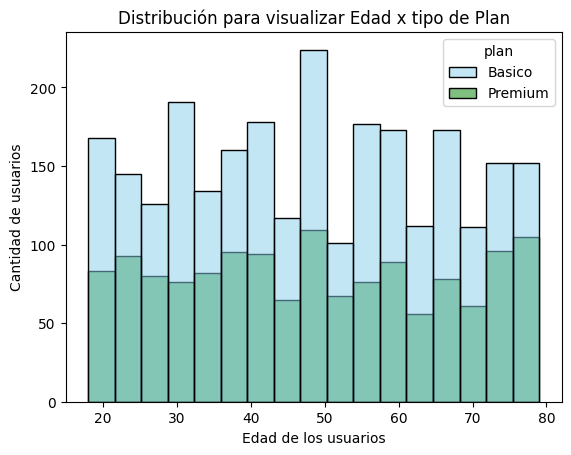

In [87]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue", "green"])
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución para visualizar Edad x tipo de Plan')
plt.show()

💡Insights:
-No existe algún patrón claro o preferencia de plan ligada a la edad. Tanto los usuarios del plan Básico como del plan Premium se distribuyen de manera muy similar y constante a lo largo de todos los rangos de edad, desde los 20 hasta cerca de los 80 años, sin que un grupo de edad específico domine relevantemente sobre otro.
- Distribución:
- Tiene una distribución uniforme y simétrica.No se observa una caída pronunciada hacia los extremos ni acumulación masiva en un solo lado (lo que descartaría un sesgo a la derecha o a la izquierda). Los datos se mantienen relativamente estables en forma de bloques horizontales a lo largo de todo el eje de la edad, distribuyéndose de manera equitativa.

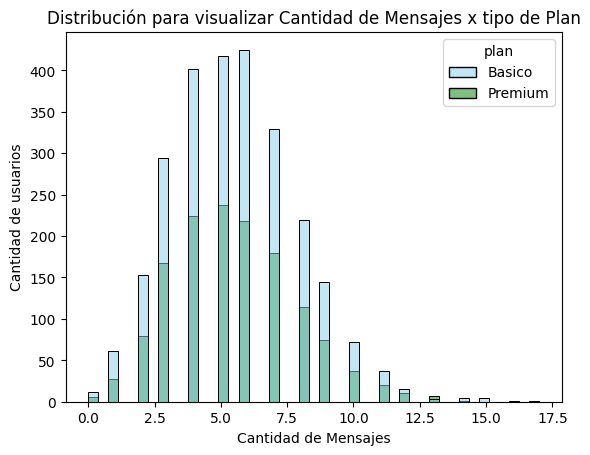

In [88]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=["skyblue", "green"])
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución para visualizar Cantidad de Mensajes x tipo de Plan')
plt.show()

💡Insights:
Los usuarios de ambos planes tienden a enviar una cantidad moderada de mensajes, concentrándose la gran mayoría entre los 3 y 7 mensajes por usuario. A partir de los 8 mensajes, el volumen de usuarios disminuye drásticamente en ambos segmentos, mostrando que son muy pocos los clientes (tanto del plan Básico como del Premium) que realizan un uso intensivo de mensajería.
-Tipo de distribución:
-Tiene una distribución sesgada a la derecha.
-La mayor parte de los datos y los picos más altos se agrupan en el lado izquierdo del gráfico (valores bajos de mensajes), mientras que la gráfica extiende una "cola" larga hacia el lado derecho (valores altos), indicando que la frecuencia decae conforme aumenta el número de mensajes.

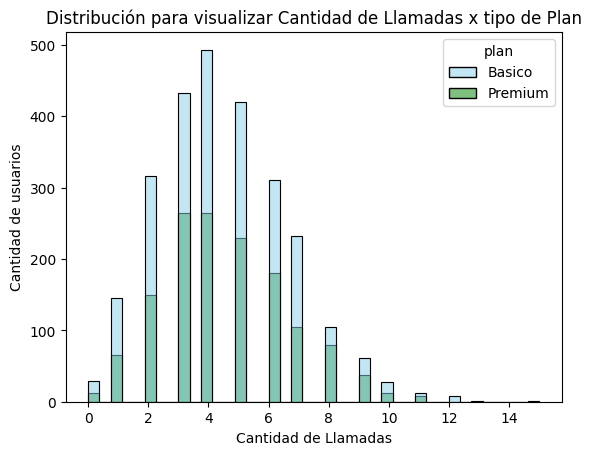

In [89]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=["skyblue", "green"])
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución para visualizar Cantidad de Llamadas x tipo de Plan')
plt.show()


💡Insights: 
-Los usuarios de ambos planes muestran un comportamiento muy similar en su consumo, concentrando la gran mayoría de sus llamadas en un rango de 2 a 6 llamadas por usuario. El pico más alto de actividad se encuentra en las 4 llamadas. A partir de las 7 llamadas, la cantidad de usuarios decae rápidamente en ambos segmentos, lo que demuestra que realizar más de 8 llamadas es un comportamiento poco común tanto en el plan Básico como en el Premium.
- Distribución:
-Tiene una distribución sesgada a la derecha.

-La mayor concentración de los datos y los picos más altos se agrupan en la parte izquierda del gráfico (valores bajos de llamadas), mientras que la distribución extiende una "cola" descendente hacia el lado derecho conforme aumenta la cantidad de llamadas.

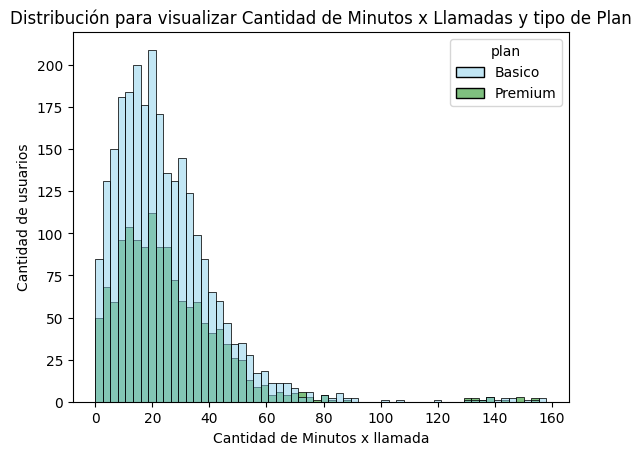

In [91]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=["skyblue", "green"])
plt.xlabel('Cantidad de Minutos x llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución para visualizar Cantidad de Minutos x Llamadas y tipo de Plan')
plt.show()


💡Insights:
-La mayoría de los usuarios de ambos planes realizan llamadas relativamente cortas, concentrándose la mayor parte entre los 5 y los 35 minutos por llamada, con un pico máximo muy marcado alrededor de los 20 minutos. El comportamiento es consistente tanto en el plan Básico como en el Premium. A partir de los 40 minutos, la cantidad de usuarios disminuye notablemente, existiendo muy pocos casos aislados que realizan llamadas de larga duración que superan los 60 minutos.
- Distribución:
-Tiene una distribución sesgada a la derecha.
-La mayor parte de los datos y los puntos más altos de las barras se agrupan en el rango de valores bajos e intermedios (el lado izquierdo del gráfico), mientras que la distribución genera una "cola" larga y descendente hacia el lado derecho debido a los pocos usuarios que registran acumulaciones muy altas de minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

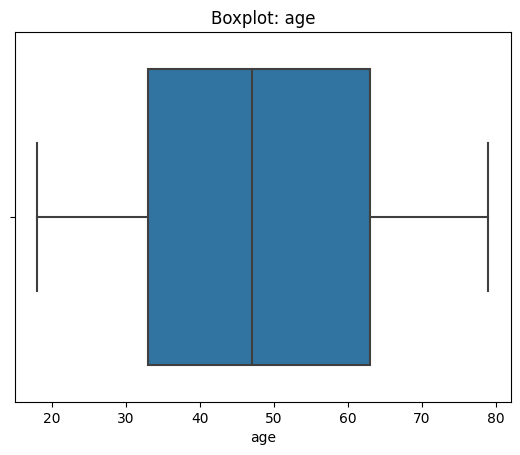

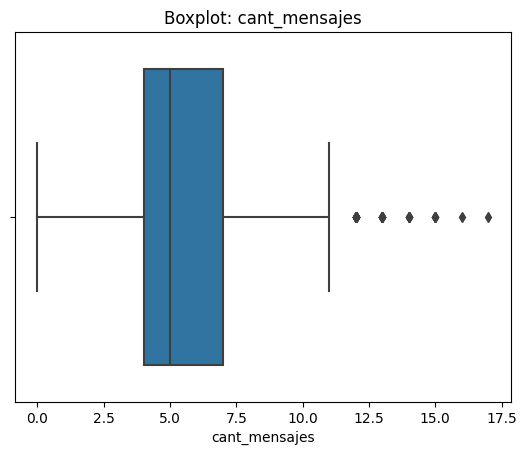

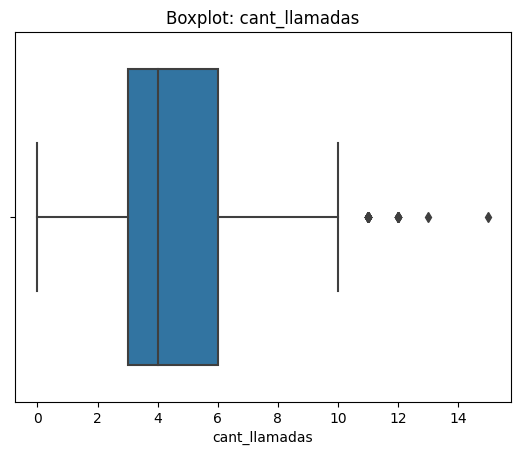

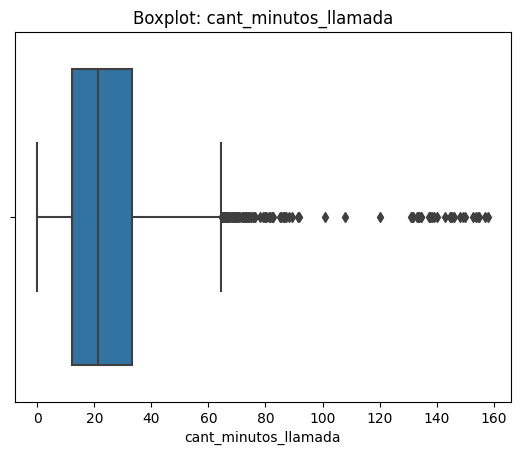

In [97]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()
    

💡Insights: 
- Age: ...(presenta o no outliers)
- No tiene outliers. La caja y sus bigotes abarcan perfectamente todo el rango de datos (de 18 a 80 años aproximadamente) sin dejar ningún punto suelto fuera de los límites.
- cant_mensajes:
- Sí existen outliers, y están ubicados exclusivamente en la parte superior derecha (los rombos negros fuera del bigote derecho, a partir del valor 12 aprox. hasta el 17).No hay outliers en el extremo inferior (el bigote izquierdo llega a 0 sin puntos aislados).
  
- cant_llamadas:
- Sí existen outliers, localizados únicamente en el lado derecho (los puntos con forma de rombo negro que se ubican a partir del valor 11 y llegan hasta 15).En el extremo inferior izquierdo no hay presencia de valores atípicos, ya que el bigote termina en 0 de forma limpia.
  
- cant_minutos_llamada:
- Sí existen outliers, y en este caso son bastante numerosos. Se localizan únicamente en el lado derecho (la gran cantidad de rombos negros que inician alrededor de los 65 minutos y se extienden hasta casi los 160 minutos). En el extremo izquierdo no hay presencia de valores atípicos, ya que el bigote inferior termina en 0.

In [98]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
for col in columnas_limites:
    # 1. Calculamos los cuartiles 1 y 3
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
# 2. Calculamos el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1
    
    # 3. Calculamos únicamente el límite superior
    limite_superior = Q3 + 1.5 * IQR
    
    # 4. Contamos cuántos registros superan este límite
    cantidad_outliers = (user_profile[col] > limite_superior).sum()
    
    print(f"Columna '{col}': Límite Superior = {limite_superior:.2f} | Cantidad de outliers: {cantidad_outliers}")


Columna 'cant_mensajes': Límite Superior = 11.50 | Cantidad de outliers: 46
Columna 'cant_llamadas': Límite Superior = 10.50 | Cantidad de outliers: 30
Columna 'cant_minutos_llamada': Límite Superior = 64.63 | Cantidad de outliers: 111


In [99]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,24.751063
std,2.358416,2.144238,18.605725
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,12.150000
50%,5.000000,4.000000,21.133333
75%,7.000000,6.000000,33.141667
max,17.000000,15.000000,158.150000


💡Insights: 
-Mantener o no outliers, porqué?
- cant_mensajes: 
- Mantener los outliers.
Por qué: Los 46 usuarios identificados con valores atípicos envían entre 12 y 17 mensajes. Estos valores representan un comportamiento de uso real e intensivo pero perfectamente razonable dentro de la mensajería. No corresponden a un error técnico ni a un fallo en el registro de datos, por lo que eliminarlos distorsionaría el análisis del patrón de uso real de los clientes.

- cant_llamadas: mantener o no outliers, porqué?
- Mantener los outliers.
-Por qué: Representan únicamente a 30 usuarios que realizan entre 11 y 15 llamadas, lo cual es una cifra completamente coherente dentro de la conducta de un usuario activo de telefonía. Al ser un volumen pequeño y factible, conservar estos datos ayuda a capturar la variabilidad natural del comportamiento del cliente sin afectar negativamente los modelos ni la interpretación general.

- cant_minutos_llamada: mantener o no outliers, porqué?
-Mantener los outliers.
-Por qué: Corresponden a un segmento clave de usuarios (111) que acumulan entre 1 y 2.5 horas totales de conversación equivalentes (65 a 160 minutos). En el sector de telecomunicaciones, este perfil de alto consumo es representativo del comportamiento real del negocio y fundamental para evaluar el uso de los planes ilimitados o Premium. Eliminar estos datos u omitirlos ocultaría a los usuarios más demandantes y rentables del servicio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [101]:
# Crear columna grupo_uso

condiciones = [(user_profile["cant_llamadas"]<5) & (user_profile["cant_mensajes"]<5), (user_profile["cant_llamadas"]<10) & (user_profile["cant_mensajes"]<10)]
valores = ['Bajo Uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')


In [106]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,24.833333,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,36.633333,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,11.233333,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,10.316667,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,9.350000,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [108]:
# Crear columna grupo_edad
condiciones = [(user_profile["age"]<30), (user_profile["age"]<60)]
valores = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')


In [111]:
# verificar cambios
user_profile.head(10)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,24.833333,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,36.633333,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,11.233333,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,10.316667,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,9.350000,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo Uso,Adulto Mayor
5,10005,5,7,48.283333,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,Uso medio,Adulto Mayor
6,10006,3,5,29.983333,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,Uso medio,Adulto
7,10007,3,5,31.716667,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,Uso medio,Adulto Mayor
8,10008,5,5,30.083333,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,Uso medio,Adulto Mayor
9,10009,5,3,6.650000,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

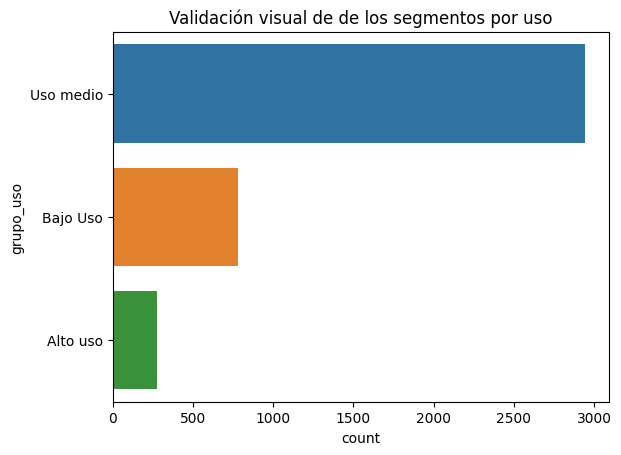

In [112]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, y='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)
plt.title('Validación visual de de los segmentos por uso')
plt.show()

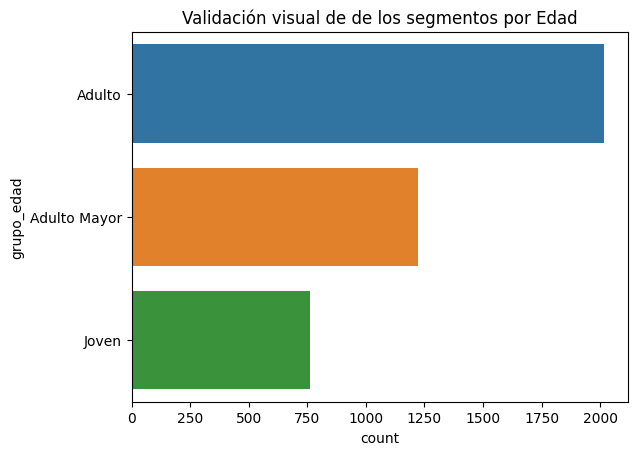

In [113]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, y='grupo_edad', order=user_profile['grupo_edad'].value_counts().index)
plt.title('Validación visual de de los segmentos por Edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Al evaluar la base de datos inicial, se identificaron inconsistencias y valores atípicos que requerían un tratamiento previo al análisis comercial:

Inconsistencias de sintaxis y nombres de columnas: Existían desalineaciones en la nomenclatura de variables (por ejemplo, el uso de total_duration frente a cant_minutos_llamada), lo que requirió un proceso de estandarización.

Presencia de valores atípicos (Outliers) en variables de consumo:

cant_mensajes: Se identificaron 46 usuarios (4.6% aproximado de la muestra analizada) que superaban el límite superior del método IQR (11.5 mensajes), registrando entre 12 y 17 mensajes.

cant_llamadas: Se identificaron 30 usuarios (3.0% de la muestra) que superaban el límite superior (10.5 llamadas), realizando entre 11 y 15 llamadas.

cant_minutos_llamada: Se identificaron 111 usuarios (11.1% de la muestra) con consumos por encima del límite superior (64.63 minutos), acumulando entre 65 y 160 minutos.


🔍 **Segmentos por Edad**
- A partir del análisis exploratorio y la creación de la variable grupo_uso, se identificaron los siguientes patrones clave:

Independencia de la Edad: La distribución por edad es totalmente uniforme y simétrica entre los 18 y los 80 años. Esto demuestra que el volumen de uso de llamadas o mensajes no depende de la edad del usuario. Los clientes jóvenes y adultos mayores contrataron los planes Básico y Premium en proporciones idénticas.


📊 **Segmentos por Nivel de Uso**
-Grupo de Consumo Medio (Mayoría): La concentración principal del negocio se ubica en consumos de 3 a 7 mensajes, 2 a 6 llamadas y promedio de 20 minutos por llamada.
-Grupo de Consumo Alto: Representado por el segmento que supera los 65 minutos acumulados o realiza más de 10 llamadas/mensajes.

➡️ Esto sugiere que ...


💡 **Recomendaciones**
Rediseño del Plan Básico: Dado que el promedio de consumo de voz oscila alrededor de los 20 minutos por llamada y entre 2 y 6 llamadas en total, el plan básico puede ajustarse a límites claros (ej. bolsas de 30 a 45 minutos) para incentivar la migración (upselling).

-Creación de un Plan Intermedio: Cubrir el salto entre el plan Básico y Premium para capturar a los usuarios que superan ligeramente la media pero no requieren un plan ilimitado.

-Segmentación Comercial por Hábitos, No por Edad:

Descartar campañas de marketing divididas por rangos de edad. Las estrategias publicitarias deben orientarse al estilo de vida digital y nivel de tráfico (voz vs. datos/mensajes), ya que el patrón de uso es idéntico a lo largo de todas las edades.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/JOELO1406/telecom-analysis